# 🏥 딥러닝 기초 CNN/전이학습 실습과제

## 과제 개요
이 과제에서는 의료 이미지 데이터셋을 활용하여 CNN과 전이학습을 적용합니다.

### 사용 데이터셋 (선택 가능)
- **MedMNIST** (권장): 의료 이미지 벤치마크 데이터셋
  - PathMNIST: 대장 조직 병리 이미지 (9 클래스)
  - DermaMNIST: 피부 병변 이미지 (7 클래스)
  - BloodMNIST: 혈액 세포 이미지 (8 클래스)
  - BreastMNIST: 유방 초음파 이미지 (2 클래스)
- **CIFAR-10**: 일반 이미지 데이터셋 (빠른 테스트용)
- **Chest X-Ray**: 폐렴 X-Ray 데이터셋 (Kaggle 다운로드 필요)

### 학습 목표
1. CNN 모델 설계 및 구현 (Day 4)
2. 데이터 증강(Augmentation) 적용
3. 전이학습(Transfer Learning) 적용 (Day 5)
4. Feature Extraction vs Fine-tuning 비교
5. 성능 비교 리포트 작성

### 제출물
- 완성된 노트북 파일 (.ipynb)
- 각 실험의 결과 분석 및 인사이트

---

## 📚 Part 0: 환경 설정 및 데이터 다운로드

In [1]:
import copy

# 필요한 라이브러리 import
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
import os
from tqdm.notebook import tqdm

# 재현성을 위한 시드 설정
torch.manual_seed(42)
np.random.seed(42)

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
Memory: 17.1 GB


In [2]:
# ============================================
# 데이터셋 선택
# ============================================
# 아래 옵션 중 하나를 선택하세요:
# - "medmnist": 의료 이미지 데이터셋 (권장 - 헬스케어 도메인!)
# - "cifar10": 일반 이미지 데이터셋 (빠른 테스트용)
# - "chest_xray": Chest X-Ray 폐렴 데이터셋 (Kaggle 다운로드 필요)

DATASET_CHOICE = "medmnist"  # "medmnist", "cifar10", "chest_xray" 중 선택

# MedMNIST 사용 시 서브 데이터셋 선택
# - "pathmnist": 대장 조직 병리 이미지 (9 클래스)
# - "dermamnist": 피부 병변 이미지 (7 클래스)
# - "bloodmnist": 혈액 세포 이미지 (8 클래스)
# - "breastmnist": 유방 초음파 이미지 (2 클래스 - 이진 분류)
MEDMNIST_TYPE = "pathmnist"

print(f"선택된 데이터셋: {DATASET_CHOICE}")

선택된 데이터셋: medmnist


### 🏥 MedMNIST: 의료 이미지 벤치마크 데이터셋

MedMNIST는 10가지 의료 이미지 데이터셋을 표준화된 28x28 형식으로 제공합니다.
- **PathMNIST**: 대장 조직 병리 이미지 (9개 클래스)
- **DermaMNIST**: 피부 병변 이미지 (7개 클래스)
- **BloodMNIST**: 혈액 세포 이미지 (8개 클래스)
- **BreastMNIST**: 유방 초음파 이미지 (2개 클래스)

**장점**:
- 헬스케어 도메인에 적합
- MNIST와 유사한 크기로 빠른 학습 가능
- 다양한 의료 이미지 유형 경험

In [3]:
# MedMNIST 설치 및 설정
if DATASET_CHOICE == "medmnist":
    # MedMNIST 라이브러리 설치

    import medmnist
    from medmnist import INFO

    # 선택한 데이터셋 정보 출력
    info = INFO[MEDMNIST_TYPE]
    print(f"\n📊 {MEDMNIST_TYPE.upper()} 데이터셋 정보:")
    print(f"  - 설명: {info['description']}")
    print(f"  - 클래스 수: {info['n_channels']} 채널, {len(info['label'])} 클래스")
    print(f"  - 클래스 목록: {info['label']}")

    # 데이터셋 클래스 및 클래스 이름 설정
    DataClass = getattr(medmnist, info['python_class'])
    NUM_CLASSES = len(info['label'])
    CLASS_NAMES = list(info['label'].values())
    N_CHANNELS = info['n_channels']

    print(f"\n✅ MedMNIST 설정 완료!")
    print(f"   클래스 수: {NUM_CLASSES}")
    print(f"   채널 수: {N_CHANNELS}")

elif DATASET_CHOICE == "cifar10":
    print("CIFAR-10 데이터셋을 사용합니다.")
    NUM_CLASSES = 10
    CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
    N_CHANNELS = 3

elif DATASET_CHOICE == "chest_xray":
    print("Chest X-Ray 데이터셋을 사용합니다.")
    print("⚠️ Kaggle에서 데이터셋을 다운로드해야 합니다.")
    DATA_DIR = "chest_xray"  # 다운로드 후 경로 설정
    NUM_CLASSES = 2
    CLASS_NAMES = ['NORMAL', 'PNEUMONIA']
    N_CHANNELS = 3


📊 PATHMNIST 데이터셋 정보:
  - 설명: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.
  - 클래스 수: 3 채널, 9 클래스
  - 클래스 목록: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}

✅ MedMNIST 설정 완료!
   클래스 수: 9
   채널 수: 3


## 📊 Part 1: 데이터 로드 및 전처리

In [4]:
# ============================================
# 이미지 변환(Transform) 정의
# ============================================
# ImageNet 정규화 값 (사전학습 모델과 동일하게 맞춤)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Chest X-Ray용 변환 (학습 - 데이터 증강 포함)
augment_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Chest X-Ray용 변환 (테스트 - 증강 없음)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [5]:
# ============================================
# 데이터셋 로드 (선택에 따라 다른 데이터셋 사용)
# ============================================

def to_rgb(x):
    """그레이스케일(1채널)을 RGB(3채널)로 변환"""
    if x.shape[0] == 1:
        return x.repeat(3, 1, 1)
    return x


if DATASET_CHOICE == "medmnist":
    # -----------------------------------------
    # MedMNIST 데이터셋 (의료 이미지)
    # 28x28 원본을 64x64로만 올려 정보 손실과 연산량 사이를 절충 --> 전이학습시 데이터 유실이 너무 심해 128, 128로 타협
    # -----------------------------------------
    medmnist_transform_train = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(to_rgb),  # 1채널 → 3채널
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    medmnist_transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(to_rgb),
        transforms.Resize((128, 128)),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    train_dataset = DataClass(split='train', transform=medmnist_transform_train, download=True)
    val_dataset = DataClass(split='val', transform=medmnist_transform_test, download=True)
    test_dataset = DataClass(split='test', transform=medmnist_transform_test, download=True)

    print(f"\n✅ {MEDMNIST_TYPE.upper()} 데이터셋 로드 완료!")

elif DATASET_CHOICE == "cifar10":
    # -----------------------------------------
    # CIFAR-10 데이터셋 (일반 이미지)
    # -----------------------------------------
    cifar_transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    cifar_transform_test = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    full_train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=cifar_transform_train
    )
    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=cifar_transform_test
    )

    # Train/Val 분할 (80:20)
    train_size = int(0.8 * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size
    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

    print("\n✅ CIFAR-10 데이터셋 로드 완료!")

elif DATASET_CHOICE == "chest_xray":
    # -----------------------------------------
    # Chest X-Ray 데이터셋 (Kaggle 다운로드 필요)
    # -----------------------------------------
    train_dataset = ImageFolder(f"{DATA_DIR}/train", transform=augment_transform)
    val_dataset = ImageFolder(f"{DATA_DIR}/val", transform=test_transform)
    test_dataset = ImageFolder(f"{DATA_DIR}/test", transform=test_transform)

    print("\n✅ Chest X-Ray 데이터셋 로드 완료!")

# 데이터셋 크기 출력
print(f"Train set: {len(train_dataset):,} samples")
print(f"Validation set: {len(val_dataset):,} samples")
print(f"Test set: {len(test_dataset):,} samples")


✅ PATHMNIST 데이터셋 로드 완료!
Train set: 89,996 samples
Validation set: 10,004 samples
Test set: 7,180 samples


In [6]:
# DataLoader 생성
BATCH_SIZE = 128
NUM_WORKERS = 4
use_persistent_workers = False
import torch

torch.set_num_threads(NUM_WORKERS)
torch.set_num_threads(NUM_WORKERS)

loader_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': device.type == 'cuda',
    'persistent_workers': use_persistent_workers,
}

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print(f"DataLoader workers: {NUM_WORKERS} | pin_memory: {loader_kwargs['pin_memory']}")
print(f"Number of batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

DataLoader workers: 4 | pin_memory: True
Number of batches - Train: 704, Val: 79, Test: 57


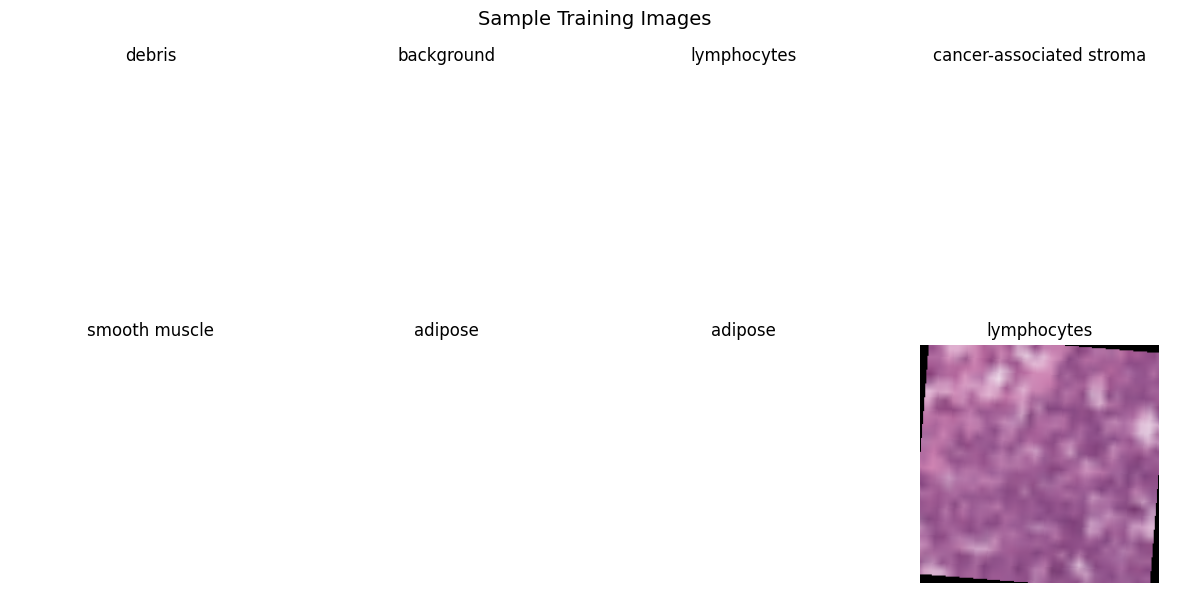

In [7]:
# 샘플 이미지 시각화
def imshow(img, title=None):
    """이미지 시각화 (정규화 역변환 포함)"""
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)

# 샘플 배치 가져오기
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.axis('off')
    imshow(images[i])
    ax.set_title(f'{CLASS_NAMES[labels[i]]}')

plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

---

## 🧠 Part 2: 기본 CNN 모델 구현 (Day 4 복습)

In [8]:
class SimpleCNN(nn.Module):
    """기본 CNN 모델"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        # 합성곱 레이어
        self.conv_layers = nn.Sequential(
            # Block 1: 224 -> 112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2: 112 -> 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3: 56 -> 28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 4: 28 -> 14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # 분류기
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

In [9]:
# ============================================
# 학습 및 검증 함수
# ============================================

def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    한 에폭 학습 수행

    Args:
        model: 학습할 모델
        train_loader: 학습 데이터 로더
        criterion: 손실 함수
        optimizer: 옵티마이저
        device: 연산 장치 (cuda/cpu)

    Returns:
        (평균 손실, 정확도)
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        # MedMNIST는 레이블이 (N, 1) 형태이므로 squeeze 처리
        if len(labels.shape) > 1:
            labels = labels.squeeze().long()
        labels = labels.to(device)

        # Forward → Loss → Backward → Update
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # 통계 누적
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(train_loader), correct / total


def validate(model, val_loader, criterion, device):
    """
    검증 수행 (gradient 계산 없음)

    Args:
        model: 평가할 모델
        val_loader: 검증 데이터 로더
        criterion: 손실 함수
        device: 연산 장치 (cuda/cpu)

    Returns:
        (평균 손실, 정확도)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # gradient 계산 비활성화
        for images, labels in val_loader:
            images = images.to(device)
            if len(labels.shape) > 1:
                labels = labels.squeeze().long()
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(val_loader), correct / total

In [10]:
# ============================================
# 전체 학습 루프
# ============================================
from tqdm.notebook import tqdm
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, num_epochs=20, patience=5, device='cpu'):
    """
    전체 학습 루프 (Early Stopping 포함)

    Args:
        model: 학습할 모델
        train_loader: 학습 데이터 로더
        val_loader: 검증 데이터 로더
        criterion: 손실 함수
        optimizer: 옵티마이저
        scheduler: 학습률 스케줄러 (선택)
        num_epochs: 최대 에폭 수
        patience: Early Stopping 인내 횟수
        device: 연산 장치 (cuda/cpu)

    Returns:
        (학습된 모델, 학습 히스토리)
    """
    model = model.to(device)
    # 학습 히스토리 저장
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    # Early Stopping 변수
    best_val_acc = 0.0
    patience_counter = 0
    best_model_state = None

    for epoch in tqdm(range(num_epochs)):
        # 학습 & 검증
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        # 히스토리 기록
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # 스케줄러 업데이트
        if scheduler:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # Early Stopping 체크
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"⏹️ Early stopping at epoch {epoch+1}")
                break

        # 진행 상황 출력 (5 에폭마다)
        if (epoch + 1) % 5 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
                  f"Train: {train_loss:.4f}/{train_acc:.4f} | "
                  f"Val: {val_loss:.4f}/{val_acc:.4f} | "
                  f"LR: {current_lr:.6f}")

    # 최적 모델 복원
    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"✅ Best model restored (Val Acc: {best_val_acc:.4f})")

    return model, history

In [11]:
# 기본 CNN 모델 학습
print("=" * 50)
print("기본 CNN 모델 학습")
print("=" * 50)

simple_cnn = SimpleCNN(num_classes=NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(simple_cnn.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

simple_cnn, simple_history = train_model(
    simple_cnn, train_loader, val_loader,
    criterion, optimizer, scheduler,
    num_epochs=20, patience=7, device=device
)

기본 CNN 모델 학습


  0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
# 학습 곡선 시각화
def plot_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history['train_loss'], label='Train', color='#8FBC8F')
    axes[0].plot(history['val_loss'], label='Val', color='#87CEEB')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train', color='#8FBC8F')
    axes[1].plot(history['val_acc'], label='Val', color='#87CEEB')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(simple_history, "Simple CNN")


KeyboardInterrupt



### ✏️ [과제 2-1] CNN 구조 분석

아래 질문에 답하세요:

1. SimpleCNN 모델에서 각 Conv 블록을 거칠 때마다 특징맵의 크기가 어떻게 변하나요?
   - 답변: (B, 3, 224, 224) → (B, 32, 112, 112) → (B, 64, 56, 56) → (B, 128, 28, 28) → (B, 256, 14, 14)

2. Global Average Pooling(GAP)을 사용하는 이유는 무엇인가요?
   - 답변: 마지막 feature map의 정보를 채널별 평균값 하나로 요약하여 압축함. 파라미터 수를 줄이고 과적합을 완하하며 각 채널이 감지한 특징이 이미지 전체적으로 얼마나 나타났는지 요약할 수 있음.

3. 학습 곡선을 보고 과적합 여부를 판단하세요.
   - 답변: 과적합 안됨

---

## 🔄 Part 3: 전이학습 - Feature Extraction (Day 5 예습)

사전학습된 모델을 특징 추출기로 사용합니다.

In [43]:
# ============================================
# Feature Extraction 모델 생성
# ============================================

def create_feature_extractor(num_classes=10):
    """
    Feature Extraction 방식의 전이학습 모델 생성
    - 사전학습된 가중치를 동결하고 마지막 분류기만 학습
    """
    # 1. 사전학습된 ResNet18 로드
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # 2. 모든 레이어 동결 (가중치 업데이트 X)
    for param in model.parameters():
        param.requires_grad = False

    # 3. 마지막 FC 레이어만 교체 (이 부분만 학습됨)
    num_features = model.fc.in_features  # 512
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, num_classes)
    )

    return model

# 모델 생성 및 파라미터 수 확인
feature_extractor = create_feature_extractor(NUM_CLASSES)
trainable_params = sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in feature_extractor.parameters())
print(f"Feature Extractor - Trainable: {trainable_params:,} / Total: {total_params:,} "
      f"({trainable_params/total_params*100:.2f}%)")

Feature Extractor - Trainable: 4,617 / Total: 11,181,129 (0.04%)


Feature Extraction 학습


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch [ 5/15] | Train: 0.9177/0.6804 | Val: 0.6806/0.7747 | LR: 0.000500
Epoch [10/15] | Train: 0.8709/0.6939 | Val: 0.6631/0.7776 | LR: 0.000250
⏹️ Early stopping at epoch 11
✅ Best model restored (Val Acc: 0.7833)


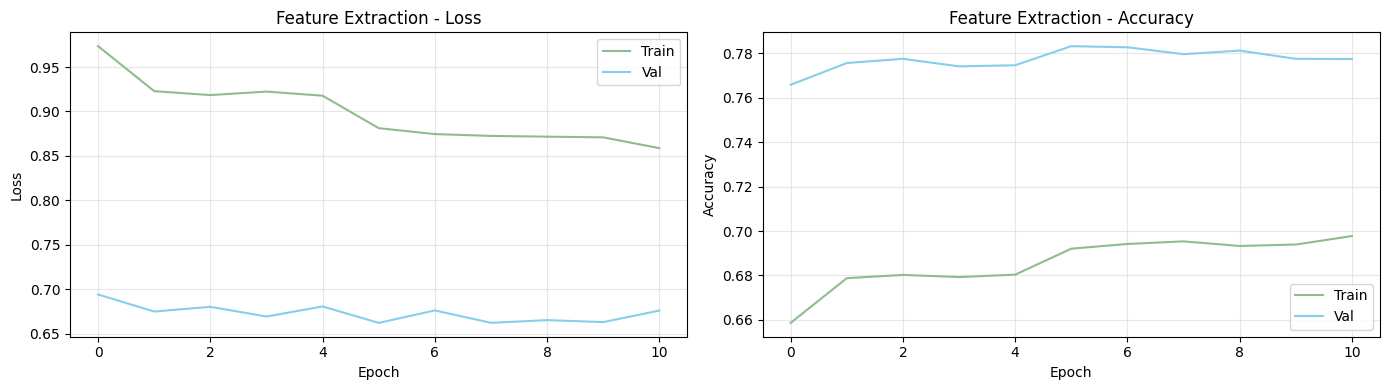

In [44]:
# Feature Extraction 학습
print("=" * 50)
print("Feature Extraction 학습")
print("=" * 50)

feature_extractor = create_feature_extractor(NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(feature_extractor.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

feature_extractor, fe_history = train_model(
    feature_extractor, train_loader, val_loader,
    criterion, optimizer, scheduler,
    num_epochs=15, patience=5, device=device
)

plot_history(fe_history, "Feature Extraction")

---

## 🎯 Part 4: 전이학습 - Fine-tuning

사전학습된 모델의 일부 레이어도 함께 학습합니다.

In [45]:
# ============================================
# Fine-tuning 모델 생성
# ============================================

def create_finetuning_model(num_classes=10, unfreeze_layers=['layer4', 'fc']):
    """
    Fine-tuning 방식의 전이학습 모델 생성
    - Feature Extraction과 달리 일부 레이어도 함께 학습
    """
    # 1. 사전학습된 ResNet18 로드
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # 2. 모든 레이어 동결
    for param in model.parameters():
        param.requires_grad = False

    # 3. 지정된 레이어만 동결 해제 (layer4, fc)
    for name, module in model.named_children():
        if name in unfreeze_layers:
            for param in module.parameters():
                param.requires_grad = True

    # 4. 마지막 FC 레이어 교체
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, num_classes)
    )

    return model

# 모델 생성 및 파라미터 수 확인
finetuning_model = create_finetuning_model(NUM_CLASSES)
trainable_params = sum(p.numel() for p in finetuning_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in finetuning_model.parameters())
print(f"Fine-tuning - Trainable: {trainable_params:,} / Total: {total_params:,} "
      f"({trainable_params/total_params*100:.2f}%)")

Fine-tuning - Trainable: 8,398,345 / Total: 11,181,129 (75.11%)


Fine-tuning 학습


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch [ 5/15] | Train: 0.1600/0.9453 | Val: 0.1101/0.9632 | LR: 0.000050
Epoch [10/15] | Train: 0.0926/0.9677 | Val: 0.0854/0.9716 | LR: 0.000025
Epoch [15/15] | Train: 0.0621/0.9781 | Val: 0.0692/0.9785 | LR: 0.000013
✅ Best model restored (Val Acc: 0.9785)


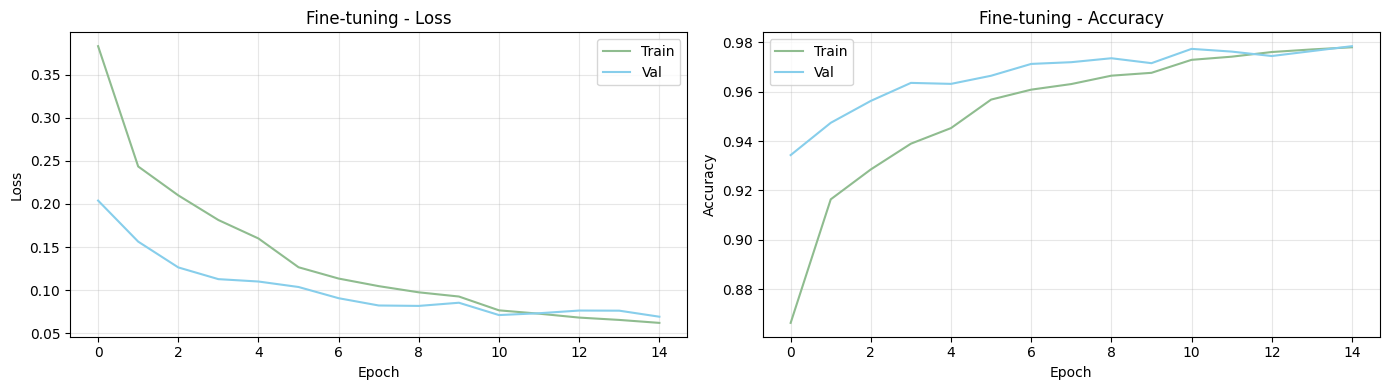

In [46]:
# Fine-tuning 학습
print("=" * 50)
print("Fine-tuning 학습")
print("=" * 50)

finetuning_model = create_finetuning_model(NUM_CLASSES)
criterion = nn.CrossEntropyLoss()

# 레이어별 다른 학습률 적용
optimizer = optim.Adam([
    {'params': finetuning_model.layer4.parameters(), 'lr': 0.0001},
    {'params': finetuning_model.fc.parameters(), 'lr': 0.001}
])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

finetuning_model, ft_history = train_model(
    finetuning_model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    num_epochs=15, patience=5, device=device
)

plot_history(ft_history, "Fine-tuning")

### ✏️ [과제 4-1] Feature Extraction vs Fine-tuning 비교

아래 질문에 답하세요:

1. Feature Extraction과 Fine-tuning의 차이점을 설명하세요.
   - 답변: feature extraction은 사전학습된 모델의 가중치를 동결하고 마지막 분류기만 새 데이터에 맞게 학습함. fine tuning은 마지막 분류기뿐 아니라 일부 레이어도 함께 학습하여 새 데이터셋에 더 맞게 조정하는 방식임.

2. 학습 가능한 파라미터 수가 다른 이유는 무엇인가요?
   - 답변: feature extraction은 마지막 fc레이어만 학습하기에 파라미터 수가 적음. fine tuning은 layer4와 fc같은 일부 레이어를 함께 학습해 파라미터 수가 더 많음.

3. Fine-tuning에서 레이어별로 다른 학습률을 사용하는 이유는 무엇인가요?
   - 답변: 기존 학습된 레이어는 특징을 잘 학습하고 있으므로 작은 학습률로 조금만 조정하고, 새로 교체한 fc 분류기는 처음부터 학습하기 때문에 더 큰 학습률을 사용한다. 기존 지식을 크게 조정하지 않으면서 새 데이터에 적응할수 있게 하는 기법이다.

4. 어떤 상황에서 Feature Extraction이 더 적합하고, 어떤 상황에서 Fine-tuning이 더 적합한가요?
   - 답변: feature extraction은 데이터가 적거나 빠르고 안정적인 학습이 필요할 때 적합할것으로 예상됨. fine tuning 은 데이터가 충부닣 많고 새 데이터가 기존 데이터와 다르거나 더 높은 성능을 위해 새 문제에 맞게 조정하고 싶을때 적합할것으로 예상됨.

---

## 📊 Part 5: 성능 비교 및 평가

In [20]:
# ============================================
# 모델 평가 함수
# ============================================

def evaluate_model(model, test_loader, device):
    """
    테스트 데이터셋에서 모델 평가

    Args:
        model: 평가할 모델
        test_loader: 테스트 데이터 로더
        device: 연산 장치 (cuda/cpu)

    Returns:
        (성능 지표 dict, 예측값 list, 실제값 list)
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            if len(labels.shape) > 1:
                labels = labels.squeeze().long()

            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 성능 지표 계산
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, average='weighted'),
        'recall': recall_score(all_labels, all_preds, average='weighted'),
        'f1': f1_score(all_labels, all_preds, average='weighted')
    }

    return metrics, all_preds, all_labels

In [48]:
# 모든 모델 평가
models_to_evaluate = {
    'Simple CNN': simple_cnn,
    'Feature Extraction': feature_extractor,
    'Fine-tuning': finetuning_model
}

all_results = {}

for name, model in models_to_evaluate.items():
    metrics, preds, labels = evaluate_model(model, test_loader, device)
    all_results[name] = {
        'metrics': metrics,
        'predictions': preds,
        'labels': labels
    }
    print(f"\n{name}:")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"  F1 Score: {metrics['f1']:.4f}")


Simple CNN:
  Accuracy: 0.8880
  Precision: 0.8926
  Recall: 0.8880
  F1 Score: 0.8852

Feature Extraction:
  Accuracy: 0.8235
  Precision: 0.8267
  Recall: 0.8235
  F1 Score: 0.8153

Fine-tuning:
  Accuracy: 0.9100
  Precision: 0.9116
  Recall: 0.9100
  F1 Score: 0.9097


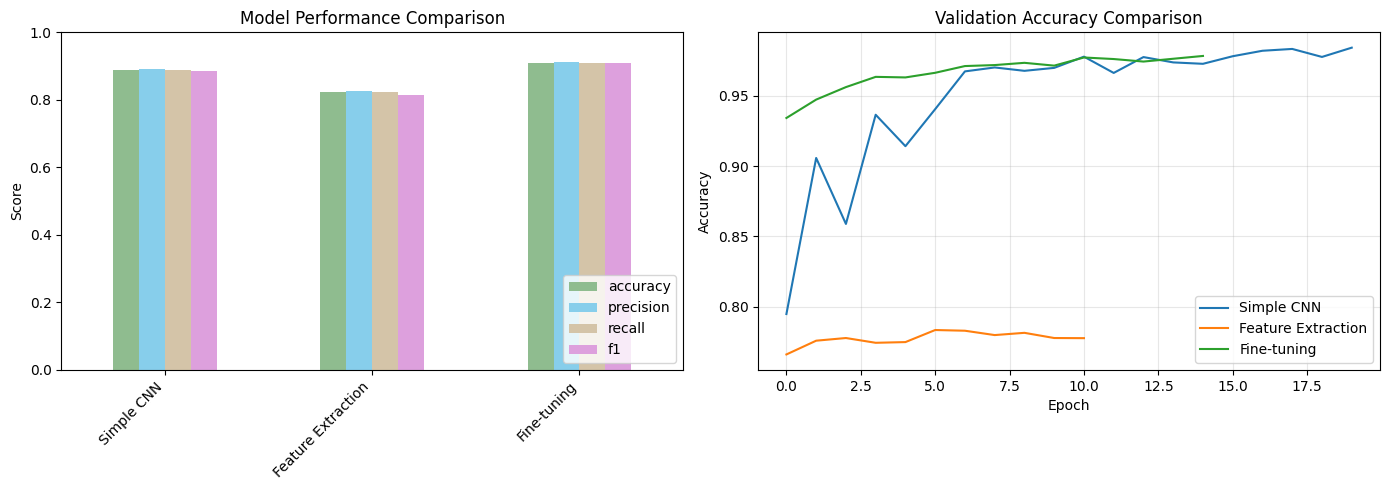


성능 요약:
                    accuracy  precision  recall      f1
Simple CNN            0.8880     0.8926  0.8880  0.8852
Feature Extraction    0.8235     0.8267  0.8235  0.8153
Fine-tuning           0.9100     0.9116  0.9100  0.9097


In [49]:
# 성능 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 성능 지표 비교
metrics_df = pd.DataFrame({
    name: result['metrics'] for name, result in all_results.items()
}).T

metrics_df.plot(kind='bar', ax=axes[0], color=['#8FBC8F', '#87CEEB', '#D4C4A8', '#DDA0DD'])
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylabel('Score')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1)

# 2. 학습 곡선 비교 (Val Accuracy)
histories = {
    'Simple CNN': simple_history,
    'Feature Extraction': fe_history,
    'Fine-tuning': ft_history
}

for name, history in histories.items():
    axes[1].plot(history['val_acc'], label=name)
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n성능 요약:")
print(metrics_df.round(4))

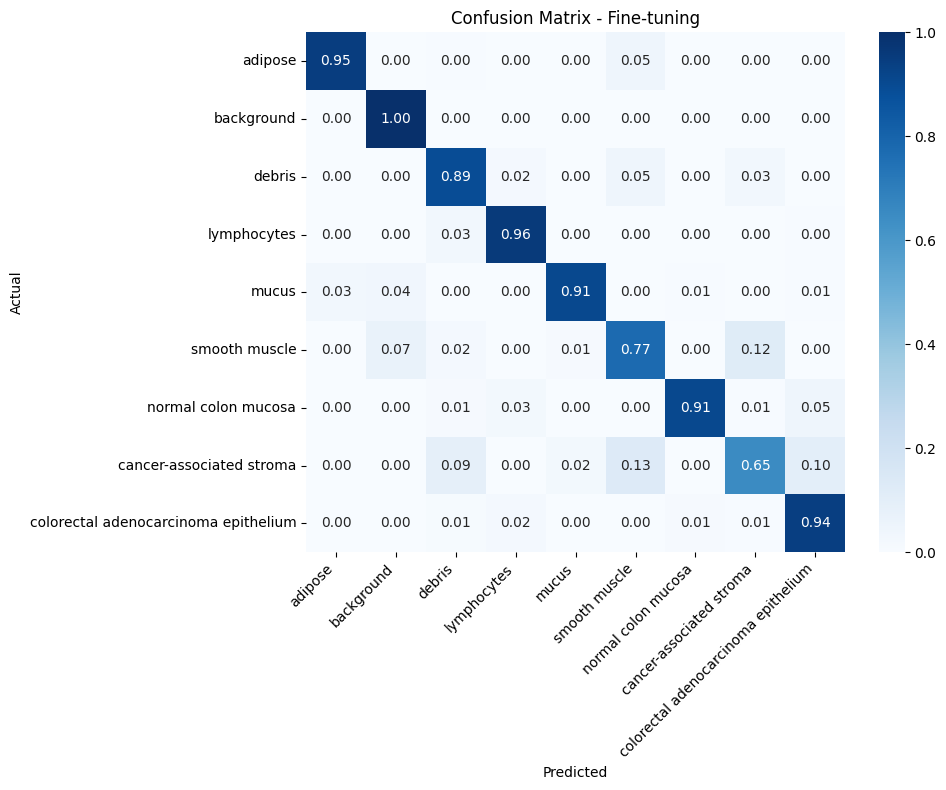

In [50]:
# 최고 성능 모델의 혼동 행렬
best_model_name = max(all_results.items(), key=lambda x: x[1]['metrics']['accuracy'])[0]
best_result = all_results[best_model_name]

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(best_result['labels'], best_result['predictions'])

# CIFAR-10의 경우 클래스가 많으므로 비율로 표시
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_title(f'Confusion Matrix - {best_model_name}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---

## 📝 Part 6: 최종 과제

### ✏️ [과제 6-1] 다른 사전학습 모델 시도하기

ResNet18 외에 다른 사전학습 모델(VGG16, EfficientNet 등)을 사용하여 성능을 비교해보세요.

In [ ]:
# TODO: 다른 사전학습 모델로 전이학습을 시도하세요

# 예시: VGG16 사용
# vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
# for param in vgg16.parameters():
#     param.requires_grad = False
# vgg16.classifier[-1] = nn.Linear(4096, NUM_CLASSES)

# 예시: EfficientNet 사용
# efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
# for param in efficientnet.parameters():
#     param.requires_grad = False
# efficientnet.classifier[-1] = nn.Linear(1280, NUM_CLASSES)

In [12]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params


def freeze_model(model):
    for param in model.parameters():
        param.requires_grad = False

In [13]:
# ================================
# VGG16 Feature Extraction
# ================================

vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# 1. 전체 파라미터 동결
freeze_model(vgg16)

# 2. 마지막 classifier만 내 데이터셋 클래스 수에 맞게 교체
# VGG16 classifier 구조:
# classifier[-1] = 마지막 Linear(4096 -> 1000)
vgg16.classifier[-1] = nn.Linear(4096, NUM_CLASSES)

# 3. GPU로 이동
vgg16 = vgg16.to(device)

# 4. 학습 가능한 파라미터 확인
total_params, trainable_params = count_parameters(vgg16)
print(f"VGG16 Total params: {total_params:,}")
print(f"VGG16 Trainable params: {trainable_params:,}")

# 5. 손실 함수와 optimizer 정의
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, vgg16.parameters()),
    lr=0.001
)

# 6. 학습
vgg16, vgg16_history = train_model(
    vgg16,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=10,
    patience=5
)

# 7. 테스트 평가
vgg16_metrics = evaluate_model(vgg16, test_loader, device)

print("VGG16 Feature Extraction Test Metrics")
print(vgg16_metrics)

VGG16 Total params: 134,297,417
VGG16 Trainable params: 36,873


  0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [14]:
# ================================
# EfficientNet-B0 Feature Extraction
# ================================

efficientnet = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)

# 1. 전체 파라미터 동결
freeze_model(efficientnet)

# 2. 마지막 classifier만 내 데이터셋 클래스 수에 맞게 교체
# EfficientNet classifier 구조:
# classifier[-1] = 마지막 Linear(1280 -> 1000)
efficientnet.classifier[-1] = nn.Linear(1280, NUM_CLASSES)

# 3. GPU로 이동
efficientnet = efficientnet.to(device)

# 4. 학습 가능한 파라미터 확인
total_params, trainable_params = count_parameters(efficientnet)
print(f"EfficientNet-B0 Total params: {total_params:,}")
print(f"EfficientNet-B0 Trainable params: {trainable_params:,}")

# 5. 손실 함수와 optimizer 정의
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, efficientnet.parameters()),
    lr=0.001
)

# 6. 학습
efficientnet, efficientnet_history = train_model(
    efficientnet,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=10,
    patience=5
)

# 7. 테스트 평가
efficientnet_metrics = evaluate_model(efficientnet, test_loader, device)

print("EfficientNet-B0 Feature Extraction Test Metrics")
print(efficientnet_metrics)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/sdh080200/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 93.8MB/s]


EfficientNet-B0 Total params: 4,019,077
EfficientNet-B0 Trainable params: 11,529


  0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

### ✏️ [과제 6-2] 최종 리포트 작성

---

## CNN/전이학습 실습 리포트

**학습자 이름**:

**작성 날짜**:

### 1. 실험 요약

| 모델 | Test Accuracy | Test F1 | 학습 시간 (예상) |
|------|---------------|---------|----------------|
| Simple CNN | | | |
| Feature Extraction | | | |
| Fine-tuning | | | |
| (추가 모델) | | | |

### 2. CNN 구조 분석

- 합성곱 연산의 역할: 지역적 특징 추출
- 풀링 연산의 역할: 중요한 특징만 압축해 남ㅁ김
- 채널 수가 증가하는 이유: 층이 깊어질수록 더 다양한 특징을 학습해야하기 때문

### 3. 전이학습 분석

- Feature Extraction의 장단점: 학습속도 빠르고 적은 데이터에서 안정적 성능을 낼 수 있음. 단점은 새로운 데이터 셋에 완전히 최적화되기 어렵다
- Fine-tuning의 장단점: 현재 데이터에 더 잘 맞게 조정할 수 있다. 시간이 오래걸리고, 데이터가 적을경우 과적합 발생 가능
- 적합한 사용 시나리오: 데이터가 적고 사전학습 데이터와 유사한 이미지라면 feature extraction이 적함. 데이터가 크거나 기존과 차이가 큰 이미지라면 fine tuning이 더 적합해보임.

### 4. 데이터 증강 효과

- 사용한 데이터 증강 기법: 이미지 회전
- 데이터 증강의 효과: 모델이 특정 이미지 형태에만 과하게 의존하는 것을 줄여 과적합 방지함.

### 5. 개선 제안

성능을 더 개선하기 위한 방법:

1.
2.
3.

### 6. 배운 점

이번 과제를 통해 배운 점:

---

## 🎉 수고하셨습니다!

### 제출 방법
1. 모든 셀을 실행하여 결과가 저장된 상태로 제출
2. 모든 ✏️ 과제 섹션에 답변 작성 완료
3. 최종 리포트 작성 완료

### 평가 기준
- 코드 실행 및 결과 (40%)
- 과제 답변의 충실성 (30%)
- 최종 리포트 분석 품질 (20%)
- 추가 모델 실험 (10%)

## 224x224 축소 Epoch 비교 실험

`resize=224x224`와 축소된 epoch 설정으로 Feature Extraction / Fine-tuning을 빠르게 비교

In [51]:
# ============================================
# 빠른 비교 실험용 224x224 DataLoader 생성
# ============================================
from copy import deepcopy

quick_train_transform_224 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(to_rgb),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

quick_test_transform_224 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(to_rgb),
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

quick_train_dataset = deepcopy(train_dataset)
quick_val_dataset = deepcopy(val_dataset)
quick_test_dataset = deepcopy(test_dataset)

quick_train_dataset.transform = quick_train_transform_224
quick_val_dataset.transform = quick_test_transform_224
quick_test_dataset.transform = quick_test_transform_224

quick_loader_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': device.type == 'cuda',
    'persistent_workers': False,
}

quick_train_loader = DataLoader(quick_train_dataset, batch_size=BATCH_SIZE, shuffle=True, **quick_loader_kwargs)
quick_val_loader = DataLoader(quick_val_dataset, batch_size=BATCH_SIZE, shuffle=False, **quick_loader_kwargs)
quick_test_loader = DataLoader(quick_test_dataset, batch_size=BATCH_SIZE, shuffle=False, **quick_loader_kwargs)

print('Quick 224 loaders ready')
print(f"Train batches: {len(quick_train_loader)}, Val batches: {len(quick_val_loader)}, Test batches: {len(quick_test_loader)}")

Quick 224 loaders ready
Train batches: 2813, Val batches: 313, Test batches: 225


224x224 Quick Feature Extraction


  0%|          | 0/5 [00:00<?, ?it/s]

⏹️ Early stopping at epoch 4
✅ Best model restored (Val Acc: 0.8367)
224x224 Quick Fine-tuning


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch [ 5/5] | Train: 0.0885/0.9696 | Val: 0.0629/0.9802 | LR: 0.000050
✅ Best model restored (Val Acc: 0.9802)


,accuracy,precision,recall,f1
Feature Extraction 224 quick,0.8508,0.8457,0.8508,0.8473
Fine-tuning 224 quick,0.9171,0.9192,0.9171,0.9159


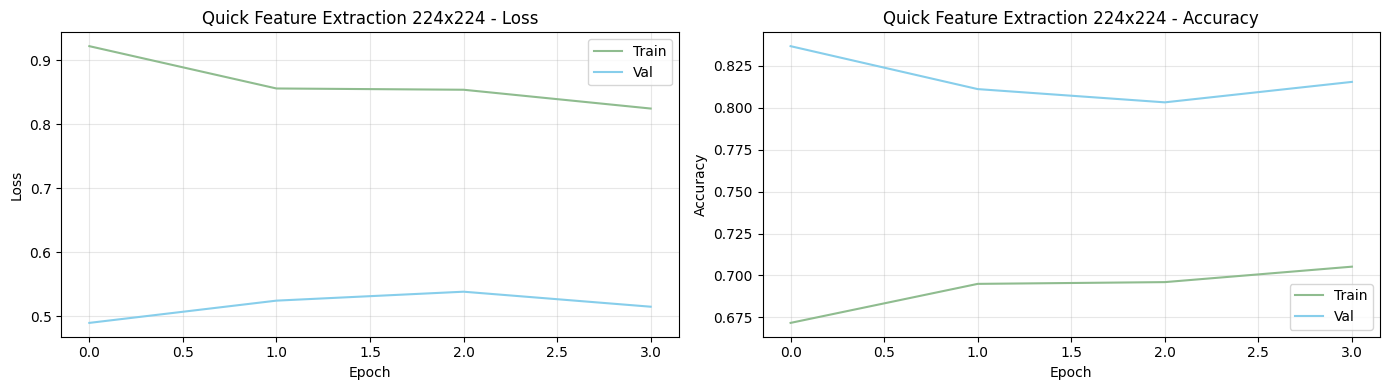

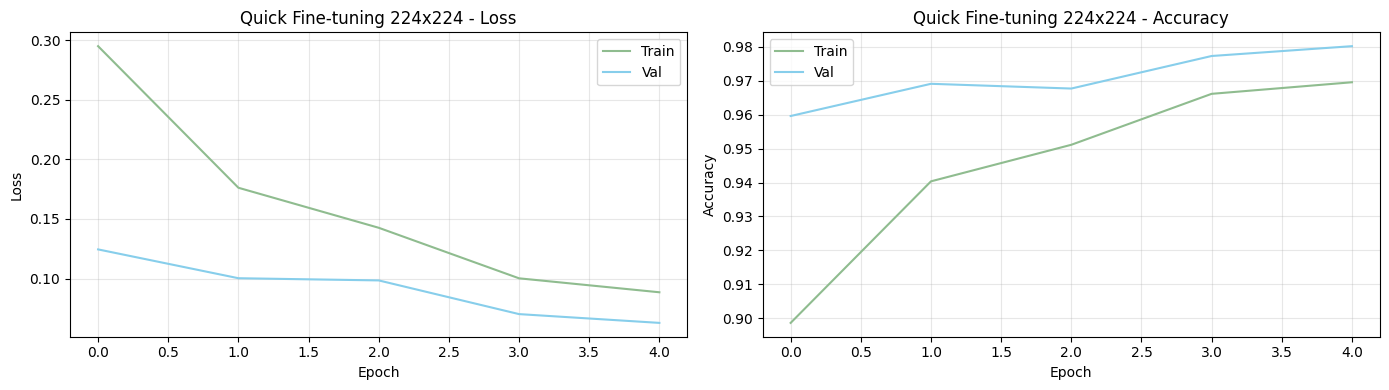

In [52]:
# ============================================
# 224x224 + 축소 Epoch 비교 실험
# ============================================
QUICK_EPOCHS = 5
QUICK_PATIENCE = 3

quick_results = {}

print('=' * 50)
print('224x224 Quick Feature Extraction')
print('=' * 50)
quick_fe = create_feature_extractor(NUM_CLASSES)
quick_fe_optimizer = optim.Adam(quick_fe.fc.parameters(), lr=0.001)
quick_fe_scheduler = optim.lr_scheduler.StepLR(quick_fe_optimizer, step_size=3, gamma=0.5)

quick_fe, quick_fe_history = train_model(
    quick_fe, quick_train_loader, quick_val_loader,
    criterion, quick_fe_optimizer, quick_fe_scheduler,
    num_epochs=QUICK_EPOCHS, patience=QUICK_PATIENCE, device=device
)
quick_fe_metrics, _, _ = evaluate_model(quick_fe, quick_test_loader, device)
quick_results['Feature Extraction 224 quick'] = quick_fe_metrics

print('=' * 50)
print('224x224 Quick Fine-tuning')
print('=' * 50)
quick_ft = create_finetuning_model(NUM_CLASSES)
quick_ft_optimizer = optim.Adam([
    {'params': quick_ft.layer4.parameters(), 'lr': 0.0001},
    {'params': quick_ft.fc.parameters(), 'lr': 0.001}
])
quick_ft_scheduler = optim.lr_scheduler.StepLR(quick_ft_optimizer, step_size=3, gamma=0.5)

quick_ft, quick_ft_history = train_model(
    quick_ft, quick_train_loader, quick_val_loader,
    criterion, quick_ft_optimizer, quick_ft_scheduler,
    num_epochs=QUICK_EPOCHS, patience=QUICK_PATIENCE, device=device
)
quick_ft_metrics, _, _ = evaluate_model(quick_ft, quick_test_loader, device)
quick_results['Fine-tuning 224 quick'] = quick_ft_metrics

quick_metrics_df = pd.DataFrame(quick_results).T
display(quick_metrics_df.round(4))

plot_history(quick_fe_history, 'Quick Feature Extraction 224x224')
plot_history(quick_ft_history, 'Quick Fine-tuning 224x224')